# Chapter 91 - Final Project: Plausible Name Generator

A name generator is a small character-level language model: it predicts one character at a time until it reaches an end marker.

This final project compares two statistical baselines with a tiny GPT and asks whether their samples are both plausible and new relative to the training data.

## Learning goals

By the end of this chapter, you will be able to:

- prepare a deterministic train-validation split of names;
- train unigram and bigram character baselines;
- train a small character-level GPT;
- generate names reproducibly from all three models;
- distinguish training copies, held-out matches, and novel samples;
- compare duplication and name-length distributions; and
- explain why novelty is necessary but not sufficient evidence of quality.

## Define success carefully

A plausible sample resembles the spelling and length patterns in the data, but plausibility requires human judgment and cannot be proved by one automatic score.

A **training copy** exactly matches a name shown during fitting.

A **held-out match** exactly matches a validation name that the model did not see during fitting.

A **novel sample** appears in neither split.

Novel strings can still be poor, and familiar names can be legitimate outputs, so we will inspect samples as well as summary statistics.

## Prepare the names

The built-in fixture keeps the project self-contained and contains 200 common names.

We normalize case, remove duplicates, shuffle with a local random-number generator, and split by complete names rather than cutting through a character stream.

In [1]:
raw_names = [
    "Emma",
    "Olivia",
    "Ava",
    "Isabella",
    "Sophia",
    "Mia",
    "Charlotte",
    "Amelia",
    "Harper",
    "Evelyn",
    "Abigail",
    "Emily",
    "Elizabeth",
    "Sofia",
    "Avery",
    "Ella",
    "Scarlett",
    "Grace",
    "Chloe",
    "Victoria",
    "Riley",
    "Aria",
    "Lily",
    "Aubrey",
    "Zoey",
    "Penelope",
    "Layla",
    "Nora",
    "Hazel",
    "Lillian",
    "Addison",
    "Stella",
    "Natalie",
    "Zoe",
    "Leah",
    "Hannah",
    "Violet",
    "Aurora",
    "Savannah",
    "Audrey",
    "Brooklyn",
    "Bella",
    "Claire",
    "Skylar",
    "Lucy",
    "Paisley",
    "Everly",
    "Anna",
    "Caroline",
    "Nova",
    "Genesis",
    "Emilia",
    "Kennedy",
    "Samantha",
    "Maya",
    "Willow",
    "Kinsley",
    "Naomi",
    "Aaliyah",
    "Elena",
    "Sarah",
    "Ariana",
    "Allison",
    "Gabriella",
    "Alice",
    "Madelyn",
    "Cora",
    "Ruby",
    "Eva",
    "Serenity",
    "Autumn",
    "Adeline",
    "Hailey",
    "Gianna",
    "Valentina",
    "Isla",
    "Eliana",
    "Quinn",
    "Nevaeh",
    "Ivy",
    "Sadie",
    "Piper",
    "Lydia",
    "Alexa",
    "Josephine",
    "Emery",
    "Julia",
    "Delilah",
    "Arianna",
    "Vivian",
    "Kaylee",
    "Sophie",
    "Brielle",
    "Madeline",
    "Peyton",
    "Rylee",
    "Clara",
    "Hadley",
    "Melanie",
    "Mackenzie",
    "Liam",
    "Noah",
    "Oliver",
    "Elijah",
    "William",
    "James",
    "Benjamin",
    "Lucas",
    "Mason",
    "Ethan",
    "Alexander",
    "Henry",
    "Jacob",
    "Michael",
    "Daniel",
    "Logan",
    "Jackson",
    "Sebastian",
    "Jack",
    "Aiden",
    "Owen",
    "Samuel",
    "Matthew",
    "Joseph",
    "Levi",
    "Mateo",
    "David",
    "John",
    "Wyatt",
    "Carter",
    "Julian",
    "Luke",
    "Grayson",
    "Isaac",
    "Jayden",
    "Theodore",
    "Gabriel",
    "Anthony",
    "Dylan",
    "Leo",
    "Lincoln",
    "Jaxon",
    "Asher",
    "Christopher",
    "Josiah",
    "Andrew",
    "Thomas",
    "Joshua",
    "Ezra",
    "Hudson",
    "Charles",
    "Caleb",
    "Isaiah",
    "Ryan",
    "Nathan",
    "Adrian",
    "Christian",
    "Maverick",
    "Colton",
    "Elias",
    "Aaron",
    "Eli",
    "Landon",
    "Jonathan",
    "Nolan",
    "Hunter",
    "Cameron",
    "Connor",
    "Santiago",
    "Jeremiah",
    "Ezekiel",
    "Angel",
    "Roman",
    "Easton",
    "Miles",
    "Robert",
    "Jameson",
    "Nicholas",
    "Greyson",
    "Cooper",
    "Ian",
    "Carson",
    "Axel",
    "Jaxson",
    "Dominic",
    "Leonardo",
    "Luca",
    "Austin",
    "Jordan",
    "Adam",
    "Xavier",
    "Jose",
    "Jace",
    "Everett",
    "Declan",
    "Evan",
    "Kayden",
    "Parker",
    "Wesley",
    "Kai",
]


def normalize_name(name: str) -> str:
    return name.strip().lower()

In [2]:
import random  # noqa: I001


names = sorted({normalize_name(name) for name in raw_names if normalize_name(name)})
split_random = random.Random(91)
split_random.shuffle(names)
split_index = int(0.8 * len(names))
training_names = sorted(names[:split_index])
validation_names = sorted(names[split_index:])
training_name_set = set(training_names)
validation_name_set = set(validation_names)

assert training_name_set.isdisjoint(validation_name_set)
print("unique names:", len(names))
print("training names:", len(training_names))
print("validation names:", len(validation_names))
print("training examples:", training_names[:10])
print("validation examples:", validation_names[:10])

unique names: 200
training names: 160
validation names: 40
training examples: ['aaliyah', 'aaron', 'abigail', 'adam', 'addison', 'adeline', 'adrian', 'aiden', 'alexa', 'alexander']
validation examples: ['aubrey', 'audrey', 'aurora', 'christian', 'clara', 'colton', 'cora', 'easton', 'ella', 'emily']


The fixed split gives every model exactly the same training information and reserves complete names for evaluation.

The validation set is small, so its metrics will be noisy and should not be treated as production benchmarks.

## Establish the length target

Name length is a simple distributional property that every generator should approximate.

We compare proportions rather than raw counts because the training, validation, and generated collections have different sizes.

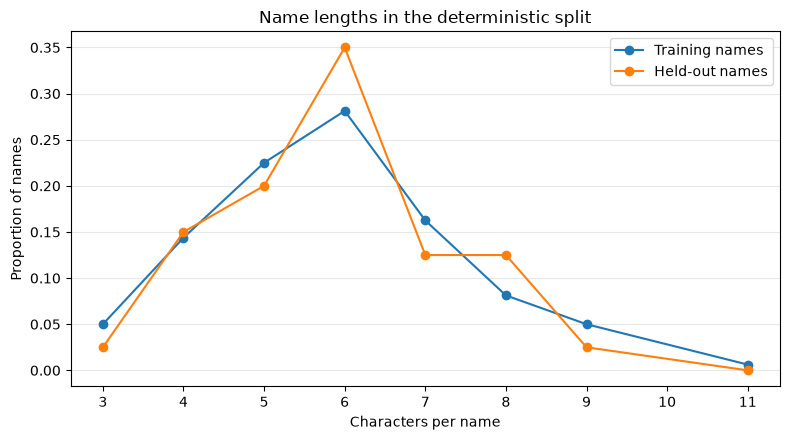

In [3]:
from collections import Counter

import matplotlib.pyplot as plt


def length_proportions(names_to_measure: list[str]) -> dict[int, float]:
    length_counts = Counter(len(name) for name in names_to_measure)
    return {
        length: count / len(names_to_measure)
        for length, count in sorted(length_counts.items())
    }


training_length_proportions = length_proportions(training_names)
validation_length_proportions = length_proportions(validation_names)
lengths = sorted(set(training_length_proportions) | set(validation_length_proportions))

plt.figure(figsize=(8, 4.5))
plt.plot(
    lengths,
    [training_length_proportions.get(length, 0.0) for length in lengths],
    marker="o",
    label="Training names",
)
plt.plot(
    lengths,
    [validation_length_proportions.get(length, 0.0) for length in lengths],
    marker="o",
    label="Held-out names",
)
plt.xlabel("Characters per name")
plt.ylabel("Proportion of names")
plt.title("Name lengths in the deterministic split")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Both splits concentrate around five to seven characters, although individual proportions vary because only 40 names are held out.

## Train a unigram baseline

A **unigram model** samples every character from one overall distribution, regardless of preceding characters.

An end marker gives the distribution a learned chance to stop after every sampled character.

In [4]:
from dataclasses import dataclass  # noqa: I001


END_TOKEN = "<end>"


@dataclass(frozen=True)
class UnigramModel:
    tokens: list[str]
    weights: list[int]


def train_unigram_model(names_to_train: list[str]) -> UnigramModel:
    token_counts: Counter[str] = Counter()
    for name in names_to_train:
        token_counts.update(name)
        token_counts[END_TOKEN] += 1
    tokens = sorted(token_counts)
    return UnigramModel(
        tokens=tokens,
        weights=[token_counts[token] for token in tokens],
    )


def generate_unigram_name(
    model: UnigramModel,
    generator: random.Random,
    maximum_length: int = 20,
) -> str:
    characters: list[str] = []
    for _ in range(maximum_length):
        token = generator.choices(model.tokens, weights=model.weights, k=1)[0]
        if token == END_TOKEN:
            break
        characters.append(token)
    return "".join(characters)


unigram_model = train_unigram_model(training_names)
unigram_random = random.Random(91)
print([generate_unigram_name(unigram_model, unigram_random) for _ in range(12)])

['', 'amavrnhpaleiwann', 'ygiciwenormedeespaa', 't', 'eaauelqipoljsmdspvle', 'elannsakile', 'tsatl', 'lce', 'rlajeyamosaraalsea', 'erlhiaaanl', 'jv', 'axisrhyacan']


The samples contain frequent letters but often lack recognizable spelling patterns because the model has no context.

## Train a bigram baseline

A **bigram model** conditions the next character on one current token.

The start marker is a context only, while letters and the end marker are valid outcomes.

Small additive smoothing gives every valid outcome nonzero weight without allowing the start marker to appear inside a name.

In [5]:
START_TOKEN = "<start>"


@dataclass(frozen=True)
class BigramModel:
    outcomes_by_context: dict[str, list[str]]
    weights_by_context: dict[str, list[float]]


def train_bigram_model(
    names_to_train: list[str], smoothing_count: float = 0.1
) -> BigramModel:
    characters = sorted({character for name in names_to_train for character in name})
    outcomes = characters + [END_TOKEN]
    contexts = [START_TOKEN] + characters
    transition_counts: dict[str, Counter[str]] = {
        context: Counter() for context in contexts
    }
    for name in names_to_train:
        sequence = [START_TOKEN, *name, END_TOKEN]
        for current_token, next_token in zip(sequence, sequence[1:], strict=False):
            transition_counts[current_token][next_token] += 1
    return BigramModel(
        outcomes_by_context={context: list(outcomes) for context in contexts},
        weights_by_context={
            context: [
                transition_counts[context][outcome] + smoothing_count
                for outcome in outcomes
            ]
            for context in contexts
        },
    )


def generate_bigram_name(
    model: BigramModel,
    generator: random.Random,
    maximum_length: int = 20,
) -> str:
    current_token = START_TOKEN
    characters: list[str] = []
    for _ in range(maximum_length):
        next_token = generator.choices(
            model.outcomes_by_context[current_token],
            weights=model.weights_by_context[current_token],
            k=1,
        )[0]
        if next_token == END_TOKEN:
            break
        characters.append(next_token)
        current_token = next_token
    return "".join(characters)


bigram_model = train_bigram_model(training_names)
bigram_random = random.Random(91)
print([generate_bigram_name(bigram_model, bigram_random) for _ in range(12)])

['ah', 'b', 'phlucker', 'cora', 'holi', 'exs', 'lichis', 'cee', 'anddyn', 'pgry', 'jphe', 'ptrletexr']


The bigram samples usually contain more familiar local transitions than the unigram samples, but one-character context cannot directly represent longer endings such as `-ella` or `-son`.

## Build separate GPT streams

The GPT uses newline as both the boundary between names and the prompt that starts a new name.

Each split gets its own stream, so no training batch can contain characters from a held-out name.

In [6]:
training_text = "\n" + "\n".join(training_names) + "\n"
validation_text = "\n" + "\n".join(validation_names) + "\n"
characters = sorted(set(training_text))
character_to_id = {character: token_id for token_id, character in enumerate(characters)}
id_to_character = {
    token_id: character for character, token_id in character_to_id.items()
}


def encode_text(text: str) -> list[int]:
    return [character_to_id[character] for character in text]


def decode_token_ids(token_ids: list[int]) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


unknown_validation_characters = sorted(set(validation_text) - set(characters))
if unknown_validation_characters:
    raise ValueError(
        f"Validation contains unknown characters: {unknown_validation_characters}"
    )

print("vocabulary:", [repr(character) for character in characters])
print("training characters:", len(training_text))
print("validation characters:", len(validation_text))

vocabulary: ["'\\n'", "'a'", "'b'", "'c'", "'d'", "'e'", "'f'", "'g'", "'h'", "'i'", "'j'", "'k'", "'l'", "'m'", "'n'", "'o'", "'p'", "'q'", "'r'", "'s'", "'t'", "'u'", "'v'", "'w'", "'x'", "'y'", "'z'"]
training characters: 1096
validation characters: 276


In [7]:
import torch  # noqa: I001


training_token_ids = torch.tensor(encode_text(training_text), dtype=torch.long)
validation_token_ids = torch.tensor(encode_text(validation_text), dtype=torch.long)


def get_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be one-dimensional.")
    number_of_starts = token_ids.shape[0] - context_length
    if number_of_starts < 1:
        raise ValueError("The token stream is too short for this context length.")
    start_indexes = torch.randint(
        0, number_of_starts, (batch_size,), generator=generator
    )
    inputs = torch.stack(
        [token_ids[start : start + context_length] for start in start_indexes]
    )
    targets = torch.stack(
        [token_ids[start + 1 : start + context_length + 1] for start in start_indexes]
    )
    return inputs, targets


batch_generator = torch.Generator().manual_seed(91)
test_inputs, test_targets = get_training_batch(
    training_token_ids, batch_size=4, context_length=16, generator=batch_generator
)
print("input shape:", tuple(test_inputs.shape))
print("target shift is correct:", torch.equal(test_inputs[:, 1:], test_targets[:, :-1]))

input shape: (4, 16)
target shift is correct: True


## Define the tiny GPT

This is the vectorized causal-attention architecture used in the preceding chapters.

Unlike the bigram model, it can condition each prediction on as many as 16 preceding characters.

In [8]:
import math  # noqa: I001
import torch


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(~causal_mask, float("-inf"))
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attended_values = self.attention_dropout(attention_weights) @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(batch_size, sequence_length, self.embedding_dimension)
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values

In [9]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_branch = self.attention(self.attention_norm(input_values))
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values


class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.Sequential(
            *[
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")
        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        hidden_values = self.transformer_blocks(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        generated_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input = generated_ids[:, -self.context_length :]
            logits, _ = self(model_input)
            next_logits = logits[:, -1] / temperature
            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_logits, effective_top_k)
                next_logits = next_logits.masked_fill(
                    next_logits < top_values[:, -1, None], float("-inf")
                )
            probabilities = torch.softmax(next_logits, dim=-1)
            next_ids = torch.multinomial(
                probabilities, num_samples=1, generator=generator
            )
            generated_ids = torch.cat([generated_ids, next_ids], dim=1)
        return generated_ids

## Train on CPU

The model is deliberately small enough for a clean CPU execution while still being more expressive than the baselines.

Evaluation uses separate random generators so diagnostic batches do not change the subsequent training batches.

In [10]:
from collections.abc import Callable  # noqa: I001


@torch.no_grad()
def estimate_loss(
    model: TinyGPT,
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    number_of_batches: int,
    generator: torch.Generator,
) -> float:
    was_training = model.training
    model.eval()
    losses: list[float] = []
    for _ in range(number_of_batches):
        inputs, targets = get_training_batch(
            token_ids, batch_size, context_length, generator
        )
        _, loss = model(inputs, targets)
        if loss is None:
            raise RuntimeError("Evaluation loss was not computed.")
        losses.append(loss.item())
    model.train(was_training)
    return sum(losses) / len(losses)


context_length = 16
training_steps = 800
evaluation_interval = 200
torch.manual_seed(91)
name_model = TinyGPT(
    vocabulary_size=len(characters),
    context_length=context_length,
    embedding_dimension=48,
    number_of_attention_heads=4,
    number_of_transformer_blocks=2,
    dropout_rate=0.1,
)
optimizer = torch.optim.AdamW(name_model.parameters(), lr=5e-4, weight_decay=0.01)
training_batch_generator = torch.Generator().manual_seed(9101)
training_evaluation_generator = torch.Generator().manual_seed(9102)
validation_evaluation_generator = torch.Generator().manual_seed(9103)
evaluation_steps: list[int] = []
training_losses: list[float] = []
validation_losses: list[float] = []


def record_losses(step: int) -> None:
    evaluation_steps.append(step)
    training_losses.append(
        estimate_loss(
            name_model,
            training_token_ids,
            batch_size=16,
            context_length=context_length,
            number_of_batches=8,
            generator=training_evaluation_generator,
        )
    )
    validation_losses.append(
        estimate_loss(
            name_model,
            validation_token_ids,
            batch_size=16,
            context_length=context_length,
            number_of_batches=8,
            generator=validation_evaluation_generator,
        )
    )
    print(
        f"step {step:>3} | train {training_losses[-1]:.3f} "
        f"| validation {validation_losses[-1]:.3f}"
    )


record_losses(0)
name_model.train()
for step in range(1, training_steps + 1):
    inputs, targets = get_training_batch(
        training_token_ids,
        batch_size=32,
        context_length=context_length,
        generator=training_batch_generator,
    )
    _, loss = name_model(inputs, targets)
    if loss is None or not torch.isfinite(loss):
        raise RuntimeError("Training loss is missing or non-finite.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(name_model.parameters(), max_norm=1.0)
    optimizer.step()
    if step % evaluation_interval == 0:
        record_losses(step)

print("parameters:", sum(parameter.numel() for parameter in name_model.parameters()))

step   0 | train 3.521 | validation 3.516


step 200 | train 2.329 | validation 2.468


step 400 | train 2.083 | validation 2.371


step 600 | train 1.851 | validation 2.421


step 800 | train 1.652 | validation 2.413
parameters: 59739


The falling losses show that the GPT learned predictable character patterns, while the held-out loss remains the more relevant check on generalization.

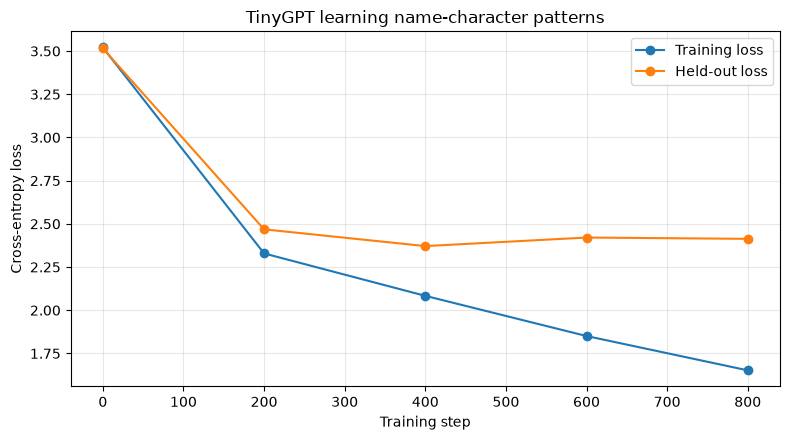

In [11]:
plt.figure(figsize=(8, 4.5))
plt.plot(evaluation_steps, training_losses, marker="o", label="Training loss")
plt.plot(evaluation_steps, validation_losses, marker="o", label="Held-out loss")
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("TinyGPT learning name-character patterns")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sample complete names

Each generator receives its own reproducible random-number source.

The collection helper rejects empty samples but stops with an error rather than retrying forever.

In [12]:
@torch.no_grad()
def generate_gpt_name(
    model: TinyGPT,
    generator: torch.Generator,
    maximum_length: int = 20,
    temperature: float = 0.9,
    top_k: int | None = 10,
) -> str:
    model.eval()
    newline_id = character_to_id["\n"]
    generated_ids = torch.tensor([[newline_id]], dtype=torch.long)
    characters_in_name: list[str] = []
    for _ in range(maximum_length):
        generated_ids = model.generate(
            generated_ids,
            number_of_new_tokens=1,
            generator=generator,
            temperature=temperature,
            top_k=top_k,
        )
        character = id_to_character[int(generated_ids[0, -1].item())]
        if character == "\n":
            break
        characters_in_name.append(character)
    return "".join(characters_in_name)


def collect_nonempty_names(
    generator_function: Callable[[], str],
    number_of_names: int,
    maximum_attempts: int,
) -> list[str]:
    generated_names: list[str] = []
    for _ in range(maximum_attempts):
        generated_name = generator_function()
        if not isinstance(generated_name, str):
            raise TypeError("The generator must return a string.")
        normalized_name = normalize_name(generated_name)
        if normalized_name:
            generated_names.append(normalized_name)
        if len(generated_names) == number_of_names:
            return generated_names
    raise RuntimeError("Could not collect enough nonempty names.")

In [13]:
unigram_sample_random = random.Random(911)
bigram_sample_random = random.Random(912)
gpt_sample_generator = torch.Generator().manual_seed(913)

unigram_names = collect_nonempty_names(
    lambda: generate_unigram_name(unigram_model, unigram_sample_random),
    number_of_names=200,
    maximum_attempts=1000,
)
bigram_names = collect_nonempty_names(
    lambda: generate_bigram_name(bigram_model, bigram_sample_random),
    number_of_names=200,
    maximum_attempts=1000,
)
gpt_names = collect_nonempty_names(
    lambda: generate_gpt_name(name_model, gpt_sample_generator),
    number_of_names=200,
    maximum_attempts=1000,
)

print("unigram".ljust(18), "bigram".ljust(18), "tiny GPT")
print("-" * 54)
for unigram_name, bigram_name, gpt_name in zip(
    unigram_names[:20], bigram_names[:20], gpt_names[:20], strict=True
):
    print(unigram_name.ljust(18), bigram_name.ljust(18), gpt_name)

unigram            bigram             tiny GPT
------------------------------------------------------
gtr                jqlintay           lenc
aiaomsisa          son                icono
nc                 exsaaneriack       ley
aao                an                 midrian
dne                deadexattu         elia
bhaodhjaraeabimylaea rasinetieroniamjonar anta
ss                 varooleopeln       ason
einenp             aideon             aley
oyniie             kdeve              colope
eanl               chab               ley
dooiv              kaly               arero
nilnorc            ena                ebydila
eluec              d                  idria
amabyendjecldaagyise jzcasilintuiniany  melizew
e                  oridyliylul        lina
nannahr            bph                carla
ail                ar                 cavery
eraeien            an                 balina
kyl                jhfivahen          abertio
aoiachodmoelinl    sorrela            caronn


The side-by-side table is the main plausibility check: unigram strings are mostly noise, bigram strings have local name-like fragments, and GPT strings can express longer patterns.

No small sample proves that one model is universally better, so the remaining checks quantify specific failure modes.

## Measure copying, held-out matches, and diversity

Exact membership is a narrow memorization check rather than a complete privacy or originality test.

The unique fraction measures sample diversity within each 200-name collection.

In [14]:
@dataclass(frozen=True)
class GenerationReport:
    model_name: str
    average_length: float
    training_copy_fraction: float
    held_out_match_fraction: float
    novel_fraction: float
    unique_fraction: float
    training_copies: list[str]
    held_out_matches: list[str]
    novel_names: list[str]


def build_generation_report(
    model_name: str, generated_names: list[str]
) -> GenerationReport:
    training_copies = [name for name in generated_names if name in training_name_set]
    held_out_matches = [name for name in generated_names if name in validation_name_set]
    novel_names = [
        name
        for name in generated_names
        if name not in training_name_set and name not in validation_name_set
    ]
    number_generated = len(generated_names)
    return GenerationReport(
        model_name=model_name,
        average_length=sum(map(len, generated_names)) / number_generated,
        training_copy_fraction=len(training_copies) / number_generated,
        held_out_match_fraction=len(held_out_matches) / number_generated,
        novel_fraction=len(novel_names) / number_generated,
        unique_fraction=len(set(generated_names)) / number_generated,
        training_copies=training_copies,
        held_out_matches=held_out_matches,
        novel_names=novel_names,
    )


reports = [
    build_generation_report("Unigram", unigram_names),
    build_generation_report("Bigram", bigram_names),
    build_generation_report("TinyGPT", gpt_names),
]

print(
    f"{'model':<10} {'avg len':>8} {'train copy':>12} "
    f"{'held out':>10} {'novel':>8} {'unique':>8}"
)
print("-" * 62)
for report in reports:
    print(
        f"{report.model_name:<10} {report.average_length:>8.2f} "
        f"{report.training_copy_fraction:>12.3f} "
        f"{report.held_out_match_fraction:>10.3f} "
        f"{report.novel_fraction:>8.3f} {report.unique_fraction:>8.3f}"
    )

model       avg len   train copy   held out    novel   unique
--------------------------------------------------------------
Unigram        5.73        0.005      0.000    0.995    0.895
Bigram         6.84        0.005      0.000    0.995    0.945
TinyGPT        5.46        0.040      0.000    0.960    0.930


In [15]:
gpt_report = reports[2]
print("TinyGPT training copies:", gpt_report.training_copies[:20])
print("TinyGPT held-out matches:", gpt_report.held_out_matches[:20])
print("TinyGPT novel samples:", gpt_report.novel_names[:30])

TinyGPT training copies: ['liam', 'jack', 'jose', 'jack', 'avery', 'avery', 'jack', 'jack']
TinyGPT held-out matches: []
TinyGPT novel samples: ['lenc', 'icono', 'ley', 'midrian', 'elia', 'anta', 'ason', 'aley', 'colope', 'ley', 'arero', 'ebydila', 'idria', 'melizew', 'lina', 'carla', 'cavery', 'balina', 'abertio', 'caronn', 'baiana', 'josam', 'dacke', 'delinna', 'ijach', 'avason', 'son', 'adelia', 'jolac', 'ariaaniel']


A held-out match is especially interesting because it cannot be a direct training-set copy, although it may still be a common pattern recovered from similar names.

The GPT’s novel list still requires manual review because exact novelty does not guarantee pronounceability.

## Compare length distributions

The final diagram overlays normalized length distributions for real training names and equal-sized generated samples.

A curve near the training curve is evidence about length calibration only, not overall quality.

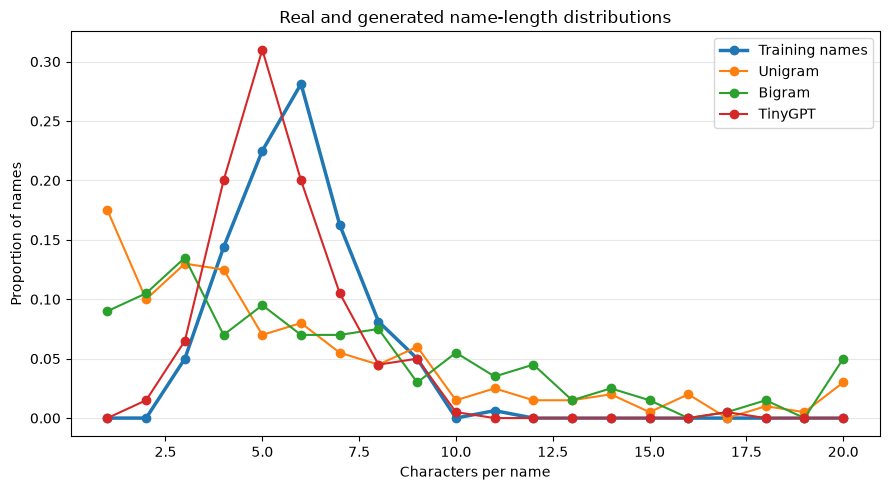

In [16]:
generated_collections = {
    "Unigram": unigram_names,
    "Bigram": bigram_names,
    "TinyGPT": gpt_names,
}
all_lengths = set(training_length_proportions)
generated_length_proportions: dict[str, dict[int, float]] = {}
for model_name, generated_names in generated_collections.items():
    proportions = length_proportions(generated_names)
    generated_length_proportions[model_name] = proportions
    all_lengths.update(proportions)
ordered_lengths = sorted(all_lengths)

plt.figure(figsize=(9, 5))
plt.plot(
    ordered_lengths,
    [training_length_proportions.get(length, 0.0) for length in ordered_lengths],
    marker="o",
    linewidth=2.5,
    label="Training names",
)
for model_name, proportions in generated_length_proportions.items():
    plt.plot(
        ordered_lengths,
        [proportions.get(length, 0.0) for length in ordered_lengths],
        marker="o",
        label=model_name,
    )
plt.xlabel("Characters per name")
plt.ylabel("Proportion of names")
plt.title("Real and generated name-length distributions")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The unigram end probability creates a broad geometric-like length distribution, while models with context can learn that stopping likelihood depends on preceding characters.

Points at length 20 include samples that reached the generation cap, so any spike at that boundary is partly a truncation artifact rather than a learned stopping preference.

## Check the short-name warning directly

Short strings have fewer character decisions and fewer possible spellings, so exact training matches can be easier to produce.

The following descriptive check compares GPT copy rates for generated names of at most four characters and for longer names.

In [17]:
def training_copy_fraction_for_group(group: list[str]) -> float | None:
    if not group:
        return None
    return sum(name in training_name_set for name in group) / len(group)


short_gpt_names = [name for name in gpt_names if len(name) <= 4]
long_gpt_names = [name for name in gpt_names if len(name) > 4]
print(
    "short names:",
    len(short_gpt_names),
    "copy fraction:",
    training_copy_fraction_for_group(short_gpt_names),
)
print(
    "longer names:",
    len(long_gpt_names),
    "copy fraction:",
    training_copy_fraction_for_group(long_gpt_names),
)

short names: 56 copy fraction: 0.10714285714285714
longer names: 144 copy fraction: 0.013888888888888888


This one run may or may not show a higher short-name copy fraction, so the result is descriptive rather than a universal law.

Larger datasets, repeated training seeds, and confidence intervals would be needed for a reliable empirical conclusion.

## Manual review checklist

Automated summaries should be paired with consistent questions:

- Can the string be pronounced without guessing extensively?
- Does it use familiar beginnings, transitions, and endings?
- Is its length plausible for this dataset?
- Does it contain suspicious repetitions?
- Is it a training copy, held-out match, or novel sample?

Name generation models spelling patterns in a small list and is not evidence that the model understands people, identity, culture, or naming practices.

## Takeaways

- Unigram and bigram baselines reveal how much character frequency and one-step transitions can already accomplish.
- A tiny GPT can use longer context, but greater capacity also creates more opportunity to reproduce training examples.
- Train-validation splitting must happen by complete names before any model is fitted.
- Training copies, held-out matches, novel samples, duplicates, and length calibration measure different properties.
- Novelty is necessary for invention but is not sufficient evidence of plausibility or quality.

The next practical step is to repeat this evaluation on a larger, documented dataset and report results across multiple random seeds.